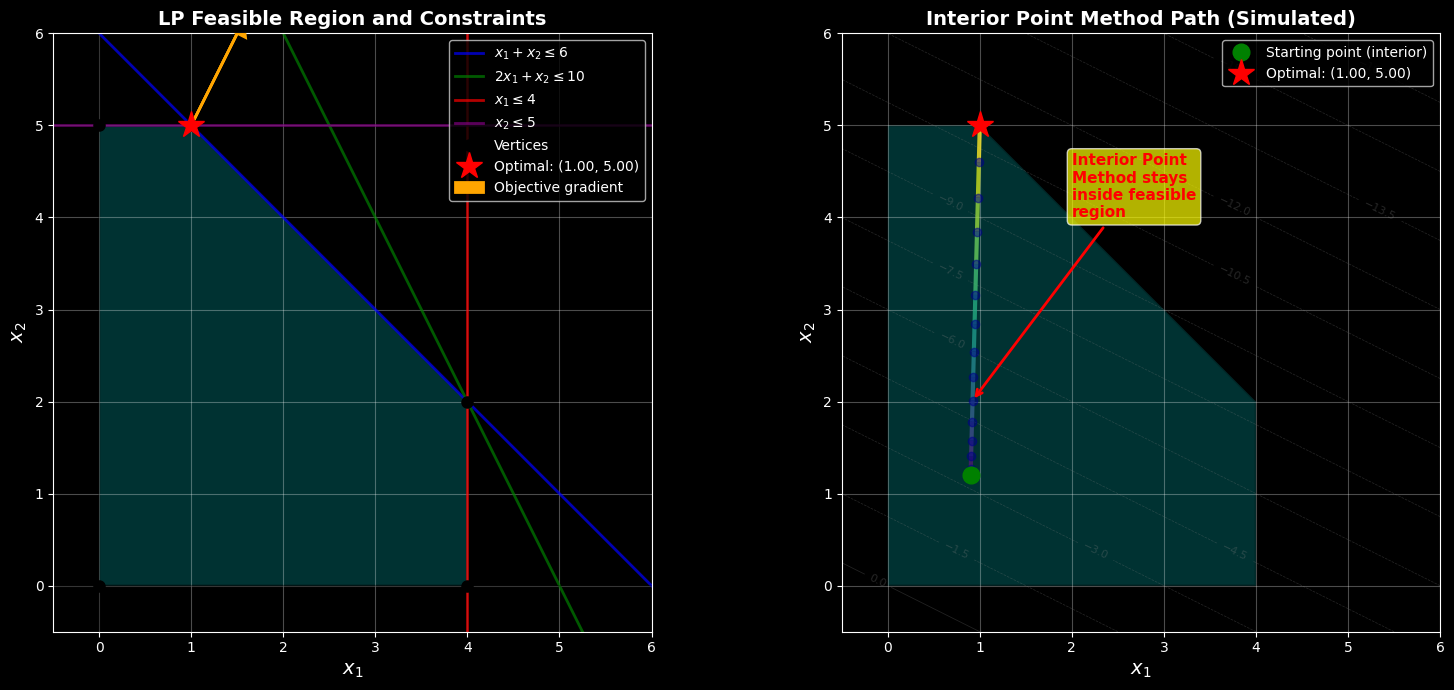

Linear Program:
Minimize: -x₁ - 2x₂  (equivalently, maximize x₁ + 2x₂)

Subject to:
  x₁ + x₂ ≤ 6
  2x₁ + x₂ ≤ 10
  x₁ ≤ 4
  x₂ ≤ 5
  x₁, x₂ ≥ 0

Optimal solution:
  x* = (1.0000, 5.0000)
  Objective value = -11.0000

Key Observations:
  • IPM starts from an interior point (green)
  • Path stays strictly inside the feasible region
  • Converges to optimal vertex (red star)
  • Unlike simplex, doesn't walk along edges
  • Gray contour lines show objective function levels


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from matplotlib.patches import Polygon
from matplotlib.collections import LineCollection

def create_2d_lp():
    """
    Create a simple 2D LP:
    minimize -x1 - 2*x2  (maximize x1 + 2*x2)
    subject to:
        x1 + x2 <= 6
        2*x1 + x2 <= 10
        x1 <= 4
        x2 <= 5
        x1, x2 >= 0
    
    Optimal solution is at (4, 2) with objective value -8
    """
    c = np.array([-1, -2])  # Minimize -x1 - 2*x2
    
    A_ub = np.array([
        [1, 1],    # x1 + x2 <= 6
        [2, 1],    # 2*x1 + x2 <= 10
        [1, 0],    # x1 <= 4
        [0, 1],    # x2 <= 5
    ])
    
    b_ub = np.array([6, 10, 4, 5])
    
    bounds = [(0, None), (0, None)]  # x1, x2 >= 0
    
    return c, A_ub, b_ub, bounds

def find_vertices(A_ub, b_ub, bounds, xlim=(0, 6), ylim=(0, 6)):
    """
    Find vertices of the feasible region by checking intersections
    """
    vertices = []
    n_constraints = len(b_ub) + 2  # Including x >= 0, y >= 0
    
    # Add constraints for x >= 0 and y >= 0
    A_all = np.vstack([A_ub, [-1, 0], [0, -1]])
    b_all = np.hstack([b_ub, 0, 0])
    
    # Check all pairs of constraints
    for i in range(n_constraints):
        for j in range(i+1, n_constraints):
            # Solve 2x2 system
            A_2x2 = np.array([A_all[i], A_all[j]])
            b_2x2 = np.array([b_all[i], b_all[j]])
            
            try:
                point = np.linalg.solve(A_2x2, b_2x2)
                
                # Check if point satisfies all constraints
                if np.all(A_all @ point <= b_all + 1e-6):
                    if xlim[0] <= point[0] <= xlim[1] and ylim[0] <= point[1] <= ylim[1]:
                        vertices.append(point)
            except:
                pass
    
    # Remove duplicates
    vertices = np.array(vertices)
    if len(vertices) > 0:
        vertices = np.unique(vertices.round(decimals=8), axis=0)
    
    return vertices

def plot_constraints(ax, A_ub, b_ub, xlim=(0, 6), ylim=(0, 6)):
    """
    Plot constraint lines
    """
    x = np.linspace(xlim[0], xlim[1], 400)
    
    labels = [
        r'$x_1 + x_2 \leq 6$',
        r'$2x_1 + x_2 \leq 10$',
        r'$x_1 \leq 4$',
        r'$x_2 \leq 5$'
    ]
    
    colors = ['blue', 'green', 'red', 'purple']
    
    for i, (a, b, label, color) in enumerate(zip(A_ub, b_ub, labels, colors)):
        if a[1] != 0:  # Not a vertical line
            y = (b - a[0] * x) / a[1]
            ax.plot(x, y, color=color, linewidth=2, label=label, alpha=0.7)
        else:  # Vertical line (x1 <= c)
            ax.axvline(b / a[0], color=color, linewidth=2, label=label, alpha=0.7)
    
    # Plot x >= 0 and y >= 0 boundaries
    ax.axhline(0, color='black', linewidth=1.5, alpha=0.3)
    ax.axvline(0, color='black', linewidth=1.5, alpha=0.3)

def plot_objective_contours(ax, c, xlim=(0, 6), ylim=(0, 6)):
    """
    Plot objective function contours
    """
    x = np.linspace(xlim[0], xlim[1], 100)
    y = np.linspace(ylim[0], ylim[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = c[0] * X + c[1] * Y
    
    contours = ax.contour(X, Y, Z, levels=15, alpha=0.3, colors='gray', linewidths=0.5)
    ax.clabel(contours, inline=True, fontsize=8)

def simulate_ipm_path(c, A_ub, b_ub, bounds, n_steps=20):
    """
    Simulate the path an interior point method might take.
    This is a simplified simulation for visualization purposes.
    """
    # Start from interior point (centroid-ish)
    vertices = find_vertices(A_ub, b_ub, bounds)
    if len(vertices) > 0:
        start = np.mean(vertices, axis=0) * 0.5
    else:
        start = np.array([1.0, 1.0])
    
    # Solve to find optimal point
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    optimal = result.x
    
    # Create a path that curves from start to optimal
    # Simulating the centering property of IPM
    path = []
    for t in np.linspace(0, 1, n_steps):
        # Quadratic interpolation to show curved path
        alpha = t ** 1.5  # Makes the path spend more time near start
        point = (1 - alpha) * start + alpha * optimal
        path.append(point)
    
    return np.array(path), start, optimal

def visualize_ipm_geometry():
    """
    Main visualization function
    """
    c, A_ub, b_ub, bounds = create_2d_lp()
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    xlim = (-0.5, 6)
    ylim = (-0.5, 6)
    
    # ========== Left plot: Feasible region and constraints ==========
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    ax1.set_xlabel(r'$x_1$', fontsize=14)
    ax1.set_ylabel(r'$x_2$', fontsize=14)
    ax1.set_title('LP Feasible Region and Constraints', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot constraints
    plot_constraints(ax1, A_ub, b_ub, xlim, ylim)
    
    # Plot feasible region
    vertices = find_vertices(A_ub, b_ub, bounds, xlim, ylim)
    if len(vertices) > 0:
        # Sort vertices by angle to form polygon
        center = np.mean(vertices, axis=0)
        angles = np.arctan2(vertices[:, 1] - center[1], vertices[:, 0] - center[0])
        sorted_vertices = vertices[np.argsort(angles)]
        
        poly = Polygon(sorted_vertices, alpha=0.2, facecolor='cyan', edgecolor='black', linewidth=2)
        ax1.add_patch(poly)
        
        # Mark vertices
        ax1.plot(vertices[:, 0], vertices[:, 1], 'ko', markersize=8, label='Vertices', zorder=5)
    
    # Solve and mark optimal point
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    if result.success:
        ax1.plot(result.x[0], result.x[1], 'r*', markersize=20, label=f'Optimal: ({result.x[0]:.2f}, {result.x[1]:.2f})', zorder=6)
    
    # Plot objective function direction (gradient)
    # The gradient points in the direction of increase
    gradient = -c  # Negative because we're minimizing -x1 - 2*x2
    if result.success:
        ax1.arrow(result.x[0], result.x[1], gradient[0]*0.5, gradient[1]*0.5, 
                 head_width=0.2, head_length=0.15, fc='orange', ec='orange', linewidth=2,
                 label='Objective gradient', zorder=4)
    
    ax1.legend(loc='upper right', fontsize=10)
    
    # ========== Right plot: IPM path ==========
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    ax2.set_xlabel(r'$x_1$', fontsize=14)
    ax2.set_ylabel(r'$x_2$', fontsize=14)
    ax2.set_title('Interior Point Method Path (Simulated)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal')
    
    # Plot feasible region again
    if len(vertices) > 0:
        poly2 = Polygon(sorted_vertices, alpha=0.2, facecolor='cyan', edgecolor='black', linewidth=2)
        ax2.add_patch(poly2)
    
    # Plot objective contours
    plot_objective_contours(ax2, c, xlim, ylim)
    
    # Simulate and plot IPM path
    path, start, optimal = simulate_ipm_path(c, A_ub, b_ub, bounds, n_steps=15)
    
    # Plot path with gradient coloring
    points = path.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    colors = np.linspace(0, 1, len(segments))
    lc = LineCollection(segments, array=colors, cmap='viridis', linewidth=3, alpha=0.8)
    ax2.add_collection(lc)
    
    # Mark points along the path
    ax2.plot(path[:, 0], path[:, 1], 'o', color='darkblue', markersize=6, alpha=0.5, zorder=3)
    
    # Mark start and end
    ax2.plot(start[0], start[1], 'go', markersize=12, label='Starting point (interior)', zorder=5)
    ax2.plot(optimal[0], optimal[1], 'r*', markersize=20, label=f'Optimal: ({optimal[0]:.2f}, {optimal[1]:.2f})', zorder=6)
    
    # Add annotations
    ax2.annotate('Interior Point\nMethod stays\ninside feasible\nregion', 
                xy=(path[5, 0], path[5, 1]), xytext=(2, 4),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=11, color='red', fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    ax2.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('ipm_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print problem details
    print("Linear Program:")
    print("=" * 60)
    print("Minimize: -x₁ - 2x₂  (equivalently, maximize x₁ + 2x₂)")
    print("\nSubject to:")
    print("  x₁ + x₂ ≤ 6")
    print("  2x₁ + x₂ ≤ 10")
    print("  x₁ ≤ 4")
    print("  x₂ ≤ 5")
    print("  x₁, x₂ ≥ 0")
    print("\nOptimal solution:")
    print(f"  x* = ({result.x[0]:.4f}, {result.x[1]:.4f})")
    print(f"  Objective value = {result.fun:.4f}")
    print("\nKey Observations:")
    print("  • IPM starts from an interior point (green)")
    print("  • Path stays strictly inside the feasible region")
    print("  • Converges to optimal vertex (red star)")
    print("  • Unlike simplex, doesn't walk along edges")
    print("  • Gray contour lines show objective function levels")
    print("=" * 60)

# Run visualization
if __name__ == "__main__":
    visualize_ipm_geometry()